In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import arc
import pairinteraction as pi
import os
from IPython.display import Latex
from scipy import constants
import pandas as pd
from pandas import DataFrame
from time import time
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
%matplotlib inline
np.set_printoptions(legacy='1.25')

h = constants.h
epsilon_0 = constants.epsilon_0
a_0 = constants.physical_constants['Bohr radius']
e = constants.e

In [2]:
colours = ('orange', 'green', 'red', 'blue', 'magenta')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   
n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [3]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1, l1, j1 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2, l2, j2 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 

l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = np.unique(magTune_import(atom1, n1, l1, j1, atom2, n2, l2, j2, l1_1, l2_1))

print(np.array(btunes))
theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]

m1_0s, m2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 0, 0


m1_1s, m2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = 0, 0
print(m2_1s)
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1_1s[m1_1i]), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1,  m=m2_1s[m2_1i])
ket1_1basis = pi.BasisAtom(atom1, n=(ket1_1.n,ket1_1.n), l=(ket1_1.l,ket1_1.l), j=(ket1_1.j,ket1_1.j))
ket2_1basis = pi.BasisAtom(atom2, n=(ket2_1.n,ket2_1.n), l=(ket2_1.l,ket2_1.l), j=(ket2_1.j,ket2_1.j))
print(ket1_1basis.kets)

[ 4.44616645  5.94607803  8.94590118 18.26678025]
[-0.5  0.5]
[KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Rb:58,P_1/2,1/2)]


In [4]:
b_index = 1

# setting target and resonant states
ket0_tuples = []
ket1_tuples = []
for ket1 in ket1basis.kets:
    for ket2 in ket2basis.kets:
         ket0_tuples.append((ket1, ket2))
for ket1_1 in ket1_1basis.kets:
    for ket2_1 in ket2_1basis.kets:
        ket1_tuples.append((ket1_1, ket2_1))
print(len(ket0_tuples))

tuple0 = ket0_tuples[1]
tuple1 = ket1_tuples[2]

deltaM = tuple1[0].m + tuple1[1].m - tuple0[0].m - tuple0[1].m

ket_tuples = (tuple0, tuple1)

print(ket_tuples)


4
((KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2)), (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,-1/2)))


In [5]:
# setting target and resonant states
# ket_tuples = [tuple0, tuple1]
ket_tuples=[tuple0]
for tuple1 in ket1_tuples: 
    ket_tuples.append(tuple1)

bs = np.array([0])
bs = np.append(bs, np.array(btunes))
# print(bs)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\Angular\\big target hams avg\\'

if not os.path.exists(datapath):
    os.makedirs(datapath)
thetaList = np.linspace(0, 360, 200)

rs = [5, 10, 15, 20, 25, 5000]

for r in rs:
    # for each b
    for mag in bs:
        if not os.path.exists(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), sep {r}um, mag {np.round(mag, 3)}1.csv'):
            # Hamiltonian dict
            eff_h_dict_elements = {'theta' : thetaList}
            eff_system = pi.EffectiveSystemPair(ket_tuples)

            eff_system.set_magnetic_field([0,0,mag], unit='G')
            
            
            for i in range(len(ket_tuples)):
                for j in range(len(ket_tuples)):
                    
                    eff_h_dict_elements.update({f'{i}{j}' : []})
            # for each theta
            for theta in thetaList:
                eff_system.set_distance(r, theta, "micrometer")
                pair_energy_pm = eff_system.get_pair_energies("MHz")[0]
                eff_system.set_minimum_number_of_ket_pairs(200)

                H = eff_system.get_effective_hamiltonian(unit="MHz") - pair_energy_pm * np.eye(len(ket_tuples))
                for i in range(len(ket_tuples)):
                    for j in range(len(ket_tuples)):
                        eff_h_dict_elements[f'{i}{j}'].append(H[i,j])
                
            pd.DataFrame(eff_h_dict_elements).to_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {np.round(mag, 3)}.csv', index=False)
            print(f'rs : {np.round(list(rs).index(r)/len(rs)*100,0)}% | bs : {list(bs).index(mag)/len(bs)*100}%')

The ket |Rb:58,P_1/2,-1/2; Cs:57,P_1/2,-1/2⟩ has only 0.612 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 7.908e-01
The ket |Rb:58,P_1/2,-1/2; Cs:57,P_1/2,1/2⟩ has only 0.612 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 7.908e-01
The ket |Rb:58,P_1/2,1/2; Cs:57,P_1/2,-1/2⟩ has only 0.612 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with

rs : 0.0% | bs : 0.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.187 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.824e-01
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.615 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 7.883e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.617 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2

rs : 0.0% | bs : 20.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.084 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.964e-01
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1

rs : 0.0% | bs : 40.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.625 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 2.971e-02
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 7.801e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.629 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The mo

rs : 0.0% | bs : 60.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.602 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 7.984e-01
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.640 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 7.683e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.648 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2

rs : 0.0% | bs : 80.0%
rs : 17.0% | bs : 0.0%


The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.562 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 8.269e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.270 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.629e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.135 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ 

rs : 17.0% | bs : 20.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/

rs : 17.0% | bs : 40.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,

rs : 17.0% | bs : 60.0%


The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.002 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.001 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.001 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ wit

rs : 17.0% | bs : 80.0%
rs : 33.0% | bs : 0.0%


The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.840 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 5.419e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.645 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 7.641e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.447 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ 

rs : 33.0% | bs : 20.0%


The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.006 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.003 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.003 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/

rs : 33.0% | bs : 40.0%


  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The

rs : 33.0% | bs : 60.0%


The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.021 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.998e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.012 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.999e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.008 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ wit

rs : 33.0% | bs : 80.0%
rs : 50.0% | bs : 0.0%


The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.871 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 4.911e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.763 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 6.470e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.632 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ 

rs : 50.0% | bs : 20.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.009 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.008 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.006 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/

rs : 50.0% | bs : 40.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.002 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.002 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.002 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,

rs : 50.0% | bs : 60.0%


  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.977e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.044 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.990e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.031 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.995e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.023 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most per

rs : 50.0% | bs : 80.0%
rs : 67.0% | bs : 0.0%


The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.855 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 5.186e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.780 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 6.252e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.695 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ 

rs : 67.0% | bs : 20.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.034 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.994e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.031 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.995e-01
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.022 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/

rs : 67.0% | bs : 40.0%


The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.006 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.006 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ has only 0.006 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,

rs : 67.0% | bs : 60.0%


The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.250 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.683e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.165 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ with overlap 9.863e-01
The ket |~Rb:58,P_1/2,1/2; ~Cs:57,P_1/2,1/2⟩ has only 0.117 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ wit

rs : 67.0% | bs : 80.0%
rs : 83.0% | bs : 0.0%
rs : 83.0% | bs : 20.0%
rs : 83.0% | bs : 40.0%
rs : 83.0% | bs : 60.0%
rs : 83.0% | bs : 80.0%


In [7]:
print(len(ket_tuples))

5


In [8]:
bs = np.array([0])
bs = np.append(bs, np.array(btunes))

H = {f'{r}{b}' : pd.read_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {np.round(b, 3)}.csv') for r in rs for b in bs}

matrix_lists = {f'{r}{b}' : [[[H[f'{r}{b}'][f'{i}{j}'][k] - H[f'{5000}{b}'][f'{i}{j}'][k] for i in range(len(ket_tuples))] for j in range(len(ket_tuples))] for k in range(len(H[f'{r}{b}']['theta']))] for r in rs for b in bs}
# matrix_lists = {f'{r}{b}' : [[[H[f'{r}{b}'][f'{i}{j}'][k] for i in range(len(ket_tuples))] for j in range(len(ket_tuples))] for k in range(len(H[f'{r}{b}']['theta']))] for r in rs for b in bs}
print(H)

eval_list = {f'{r}{b}' : [np.linalg.eigh(matrix)[0] for matrix in matrix_lists[f'{r}{b}']] for r in rs for b in bs}
evec_list = {f'{r}{b}' : [np.linalg.eigh(matrix)[1] for matrix in matrix_lists[f'{r}{b}']] for r in rs for b in bs}
thetas = {f'{r}{b}' : H[f'{r}{b}']['theta'] for r in rs for b in bs}

{'50.0':           theta        00        01         02         03        04        10  \
0      0.000000 -1.867474  0.000000 -18.899384 -18.899384  0.000000  0.000000   
1      1.809045 -1.868591 -0.894493 -18.871132 -18.871132  0.894493 -0.894493   
2      3.618090 -1.871936 -1.785421 -18.786489 -18.786489  1.785421 -1.785421   
3      5.427136 -1.877497 -2.669231 -18.645792 -18.645792  2.669231 -2.669231   
4      7.236181 -1.885252 -3.542401 -18.449602 -18.449602  3.542401 -3.542401   
..          ...       ...       ...        ...        ...       ...       ...   
195  352.763819 -1.885252  3.542401 -18.449602 -18.449602 -3.542401  3.542401   
196  354.572864 -1.877497  2.669231 -18.645792 -18.645792 -2.669231  2.669231   
197  356.381910 -1.871936  1.785421 -18.786489 -18.786489 -1.785421  1.785421   
198  358.190955 -1.868591  0.894493 -18.871132 -18.871132 -0.894493  0.894493   
199  360.000000 -1.867474  0.000000 -18.899384 -18.899384  0.000000  0.000000   

            11    

0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2))
1 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,-1/2))
2 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2))
3 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,-1/2))
4 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,1/2))


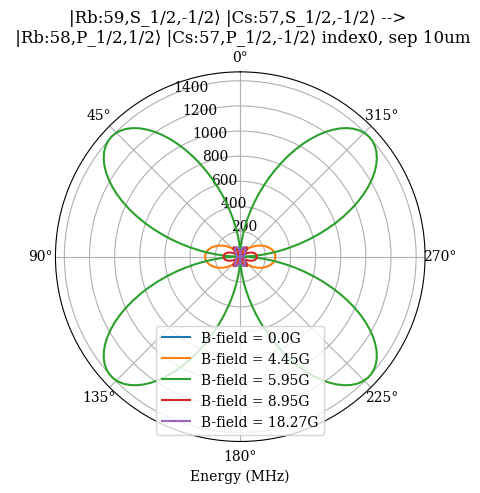

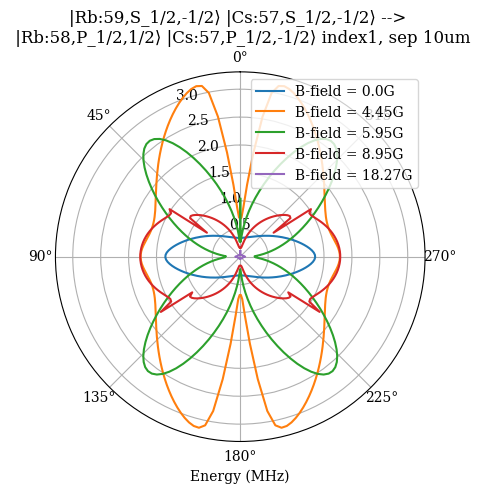

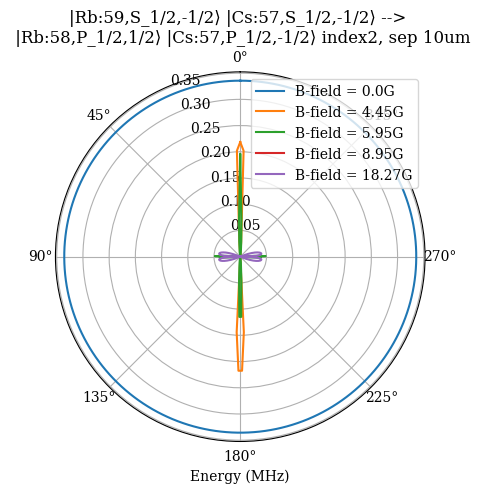

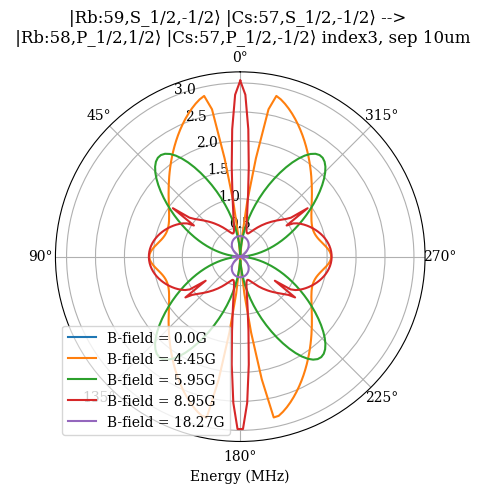

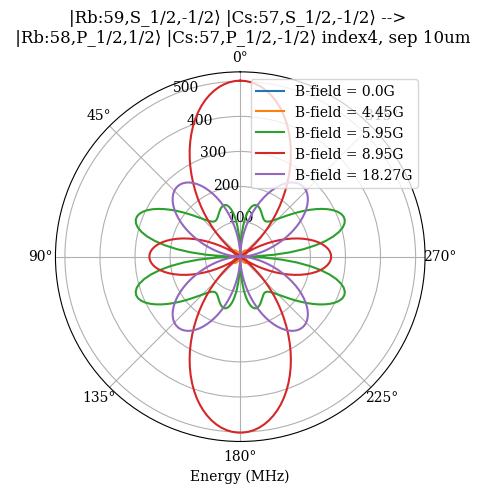

C:\Users\Tommy\AppData\Local\Temp\ipykernel_25664\4271422382.py:37: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})


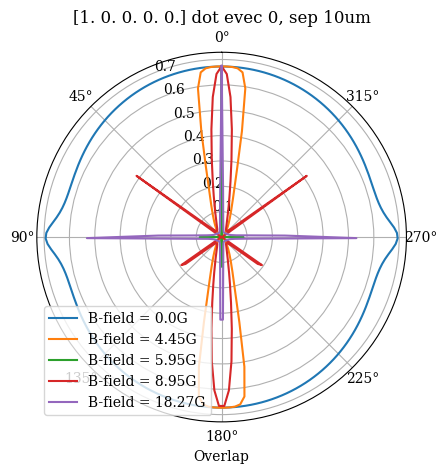

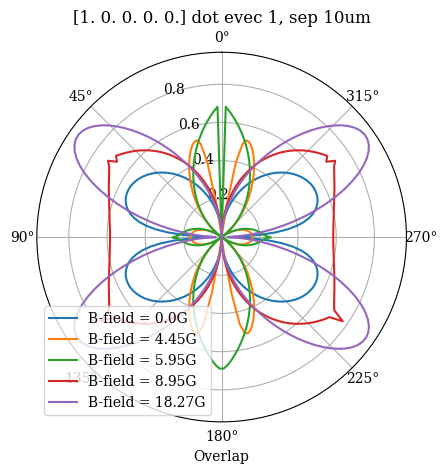

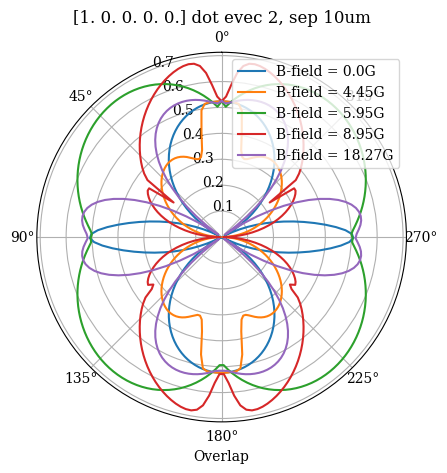

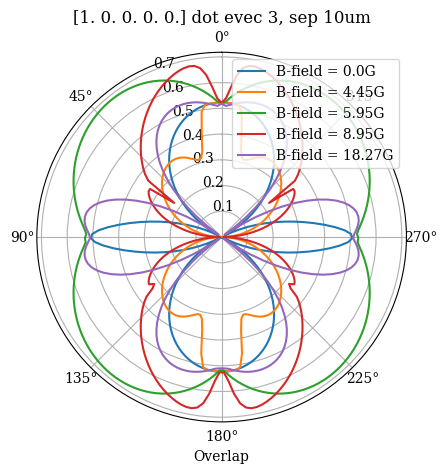

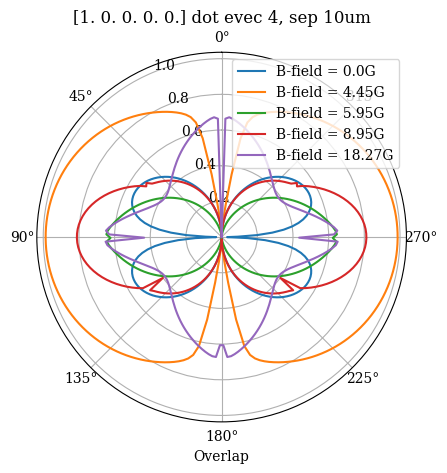

...

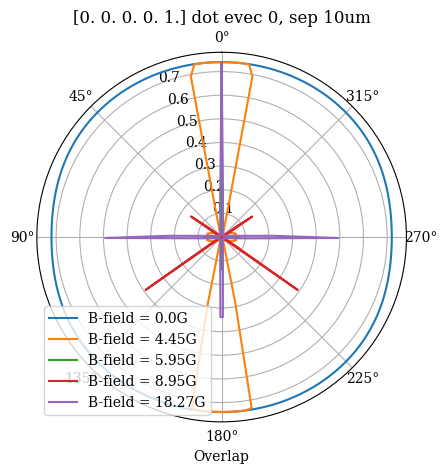

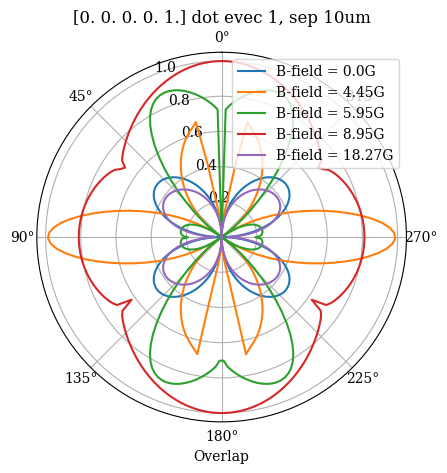

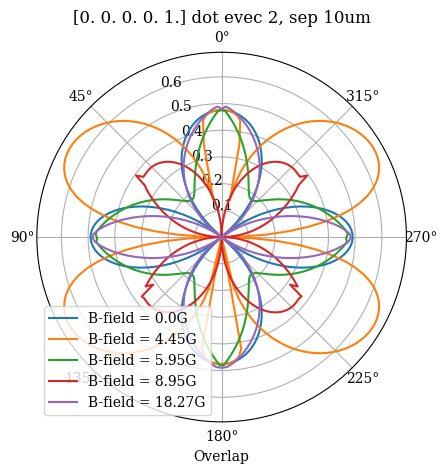

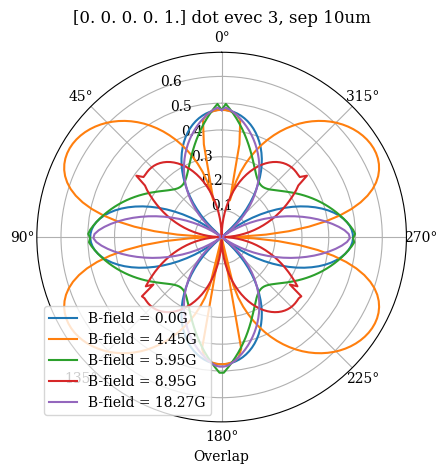

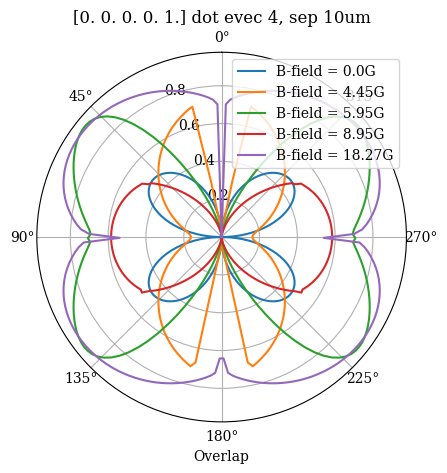

In [67]:
tuple0 = ket0_tuples[0]
tuple1 = ket1_tuples[2]
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\2x2 hams avg\\'

if not os.path.exists(figpath + 'eigenenergies\\'):
    os.makedirs(figpath + 'eigenenergies\\')
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')

tups = np.eye(len(ket_tuples))

overlap = {f'{r}{b}' : {f'{index}{tup}' : [abs(np.round(np.dot(tup, evec[index]),5)) for evec in evec_list[f'{r}{b}']] for index in range(len(ket_tuples)) for tup in tups} for r in rs for b in bs}
Ediag = {f'{r}{b}' : {f'{index}' : [eval[index] for eval in eval_list[f'{r}{b}']] for index in range(len(ket_tuples))} for r in rs for b in bs}

r = 10


for index in range(len(ket_tuples)):
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location("N")
    for b in bs:
        ax.plot(np.radians(thetas[f'{r}{b}']), abs(np.array(Ediag[f'{r}{b}'][f'{index}'])), "-", label = fr'B-field = {np.round(b,2)}G')

    ax.legend()
    ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index}, sep {r}um')
    ax.set_xlabel(r"Energy (MHz)")
    plt.savefig(figpath + f'eigenenergies\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

plt.show()


for tup in tups:
    for index in range(len(ket_tuples)):
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
        ax.set_theta_zero_location("N")
        for b in bs:         
            ax.plot(np.radians(thetas[f'{r}{b}']), overlap[f'{r}{b}'][f'{index}{tup}'], label = fr'B-field = {np.round(b,2)}G') 
        ax.legend()
        ax.set_xlabel(r"Overlap")
        ax.set_title(f'{tup} dot evec {index}, sep {r}um')
        
        plt.savefig(figpath + f'\\overlaps\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

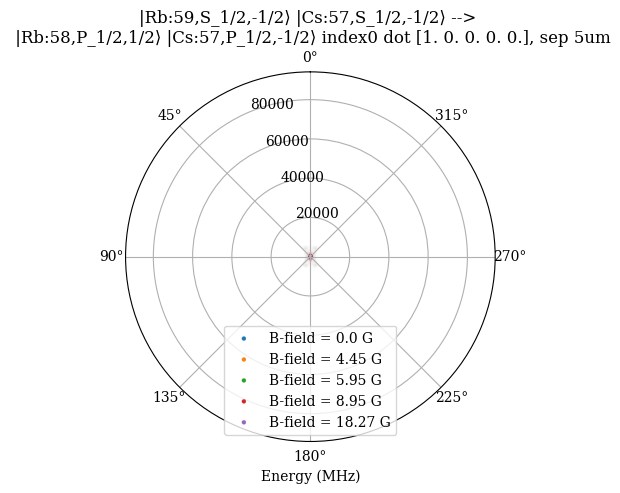

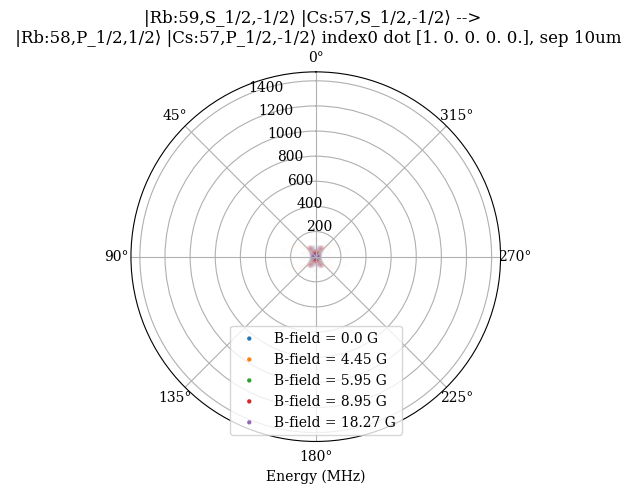

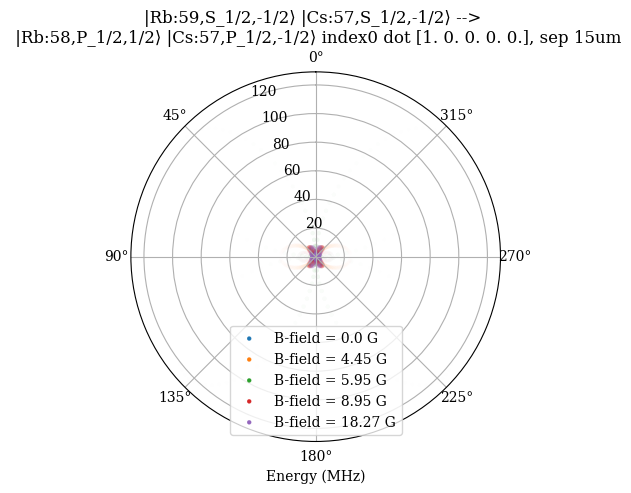

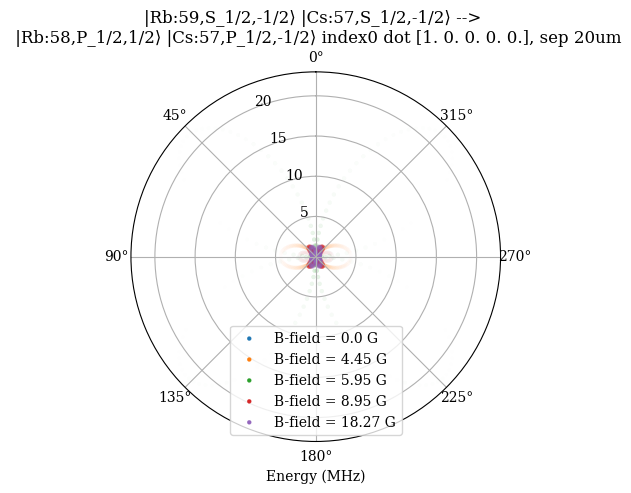

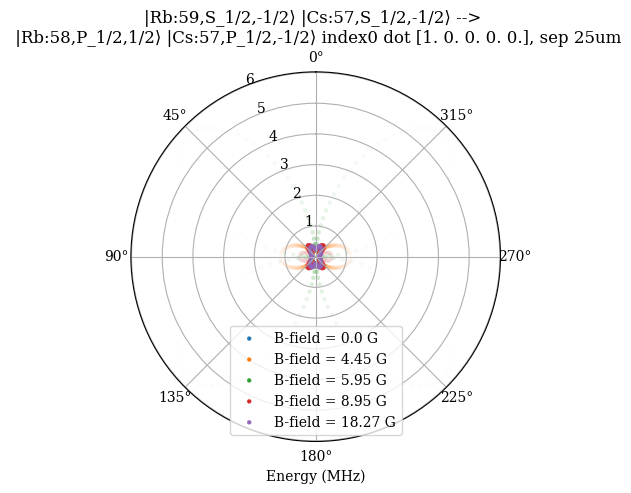

...

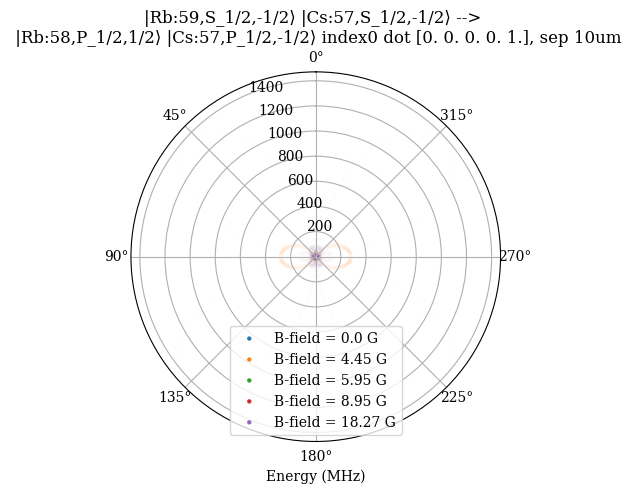

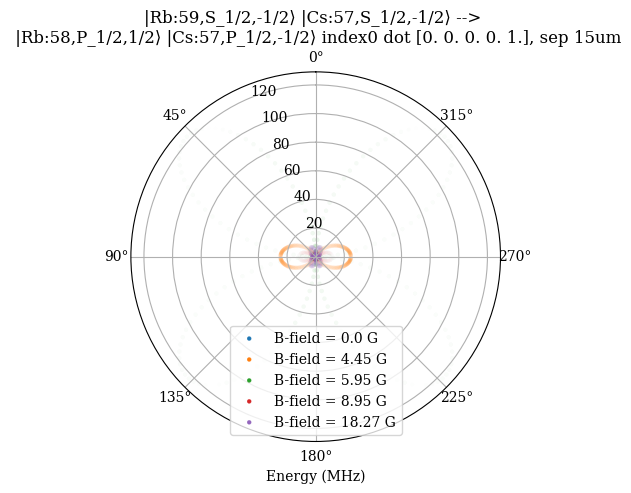

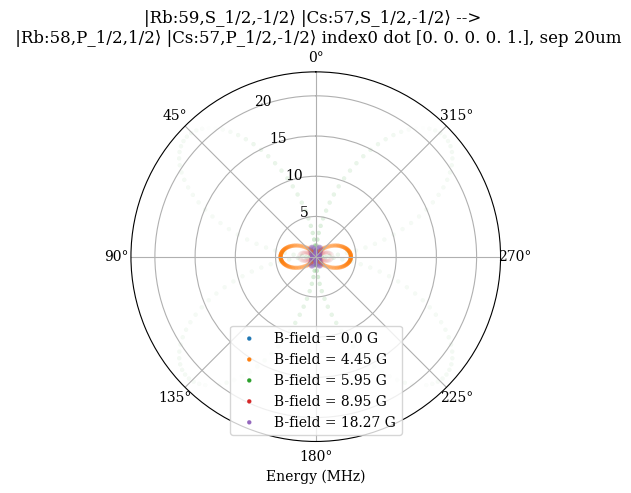

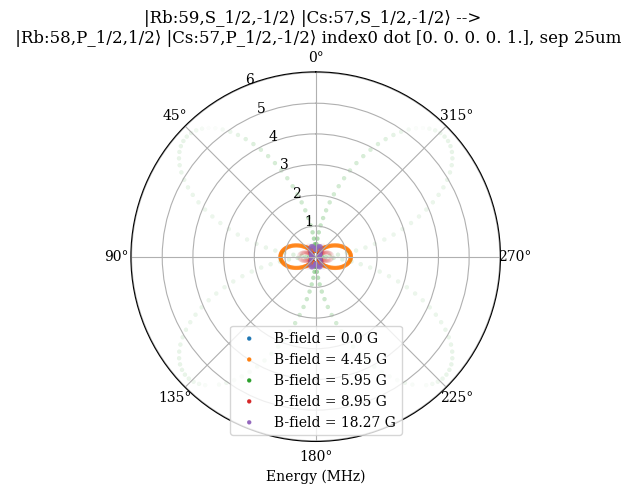

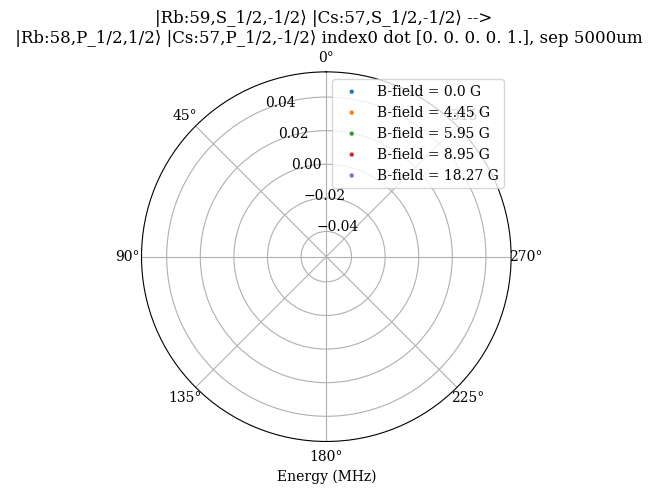

In [68]:
colours = ('orange', 'green', 'red', 'blue', 'purple')
prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
if not os.path.exists(figpath + 'eigenenergies dots\\'):
    os.makedirs(figpath + 'eigenenergies dots\\')
for tup in tups:
    for r in rs:
    
        for index in range(1):
            fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
            ax.set_theta_zero_location("N")
            for i, b in enumerate(bs):

                # 1. Convert the base color name to RGB (e.g., 'red' -> [1, 0, 0])
                base_rgb = mcolors.to_rgb(colours[i])
                
                # 2. Build the RGBA array: (N, 4)
                # This stores the specific relevance for every point in THIS set
                rgba = np.zeros((len(Ediag[f'{r}{b}'][f'{index}']), 4))
                rgba[:, :3] = base_rgb
                rgba[:, 3] = overlap[f'{r}{b}'][f'{index}{tup}']
                
                ax.scatter(np.radians(thetas[f'{r}{b}']),
                        abs(np.array(Ediag[f'{r}{b}'][f'{index}'])),
                        c=rgba,
                        marker='.',
                        linewidths=.1,
                        label = fr'B-field = {str(np.round(b,2))} G')
                
            leg = plt.legend()
            for lh in leg.legend_handles:
                if lh is not None:  # Use 'is not None' instead of 'if lh:'
                    lh.set_alpha(1)
            ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index} dot {tup}, sep {r}um')
            ax.set_xlabel(r"Energy (MHz)")
            plt.savefig(figpath + f'eigenenergies dots\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index} dot tup.png')

        plt.show()
        plt.close()

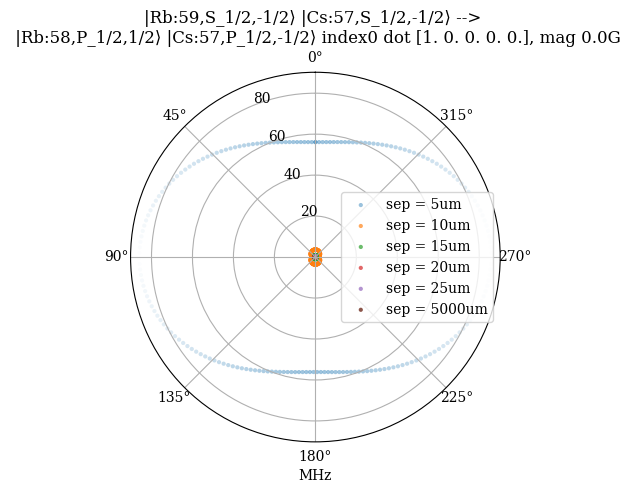

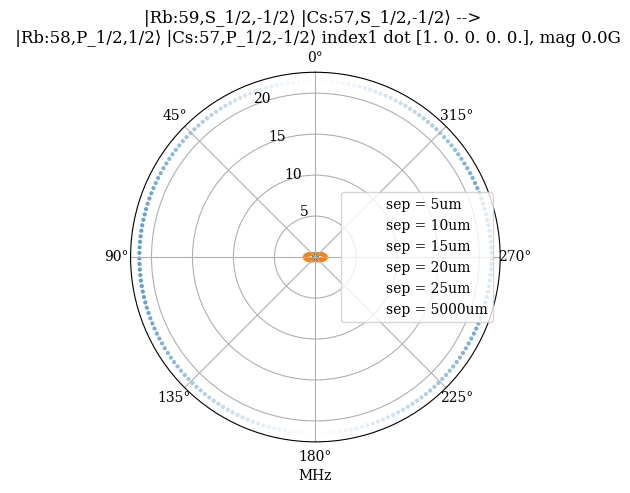

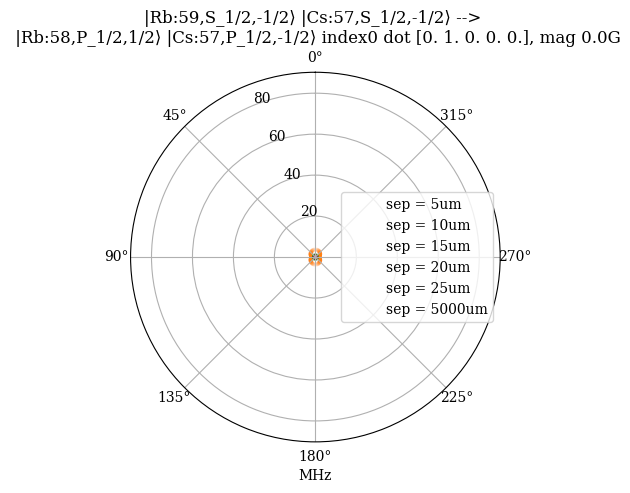

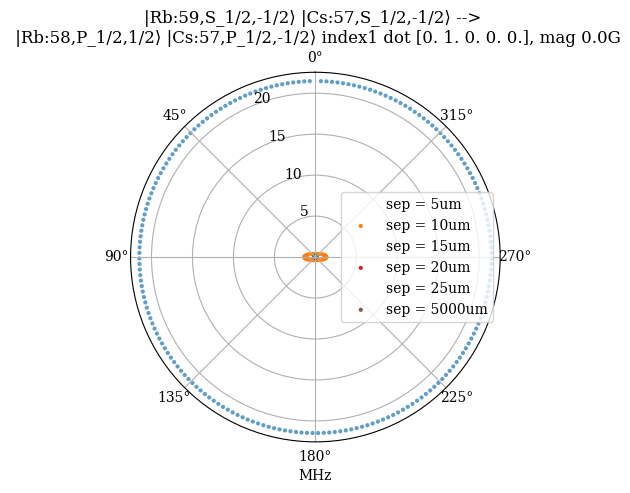

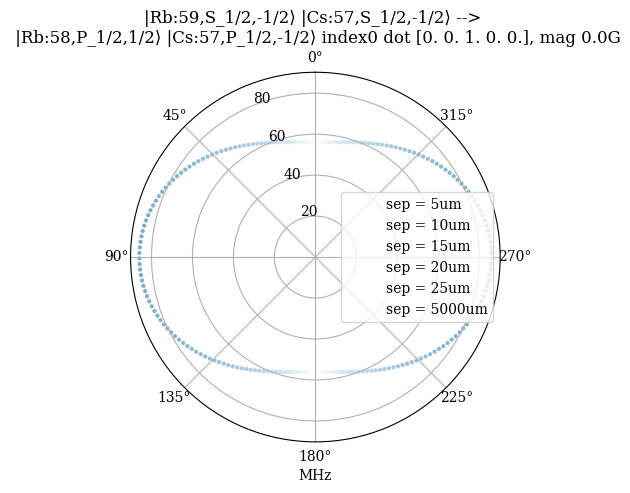

...

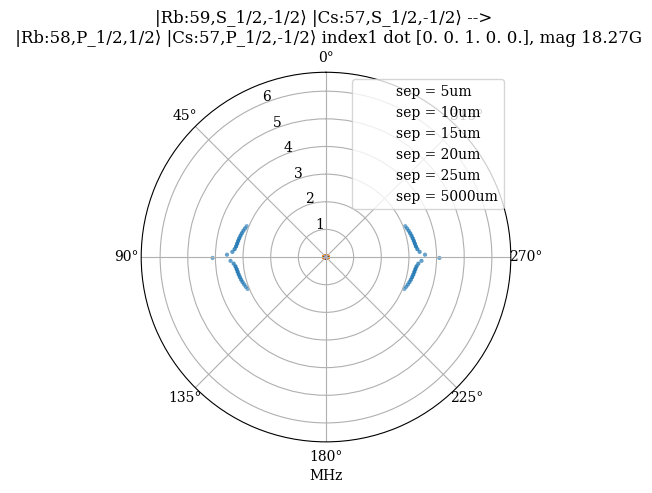

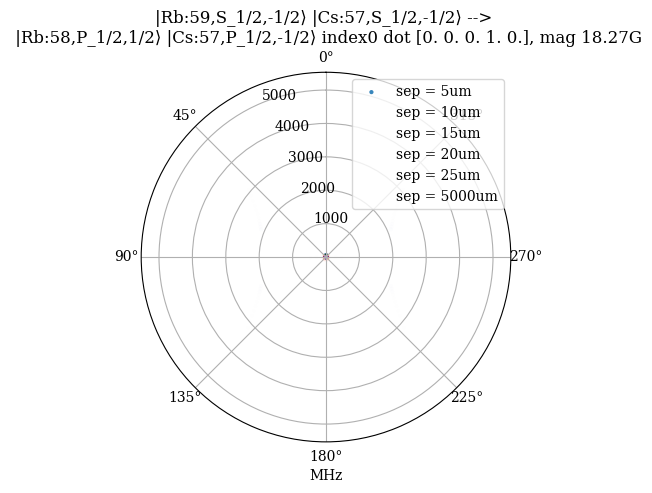

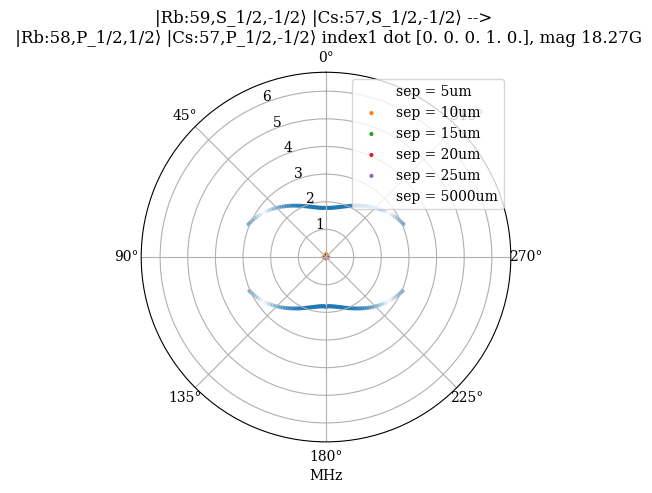

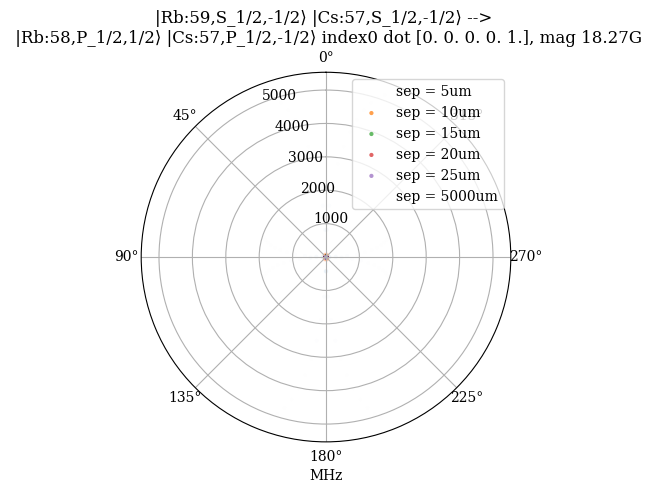

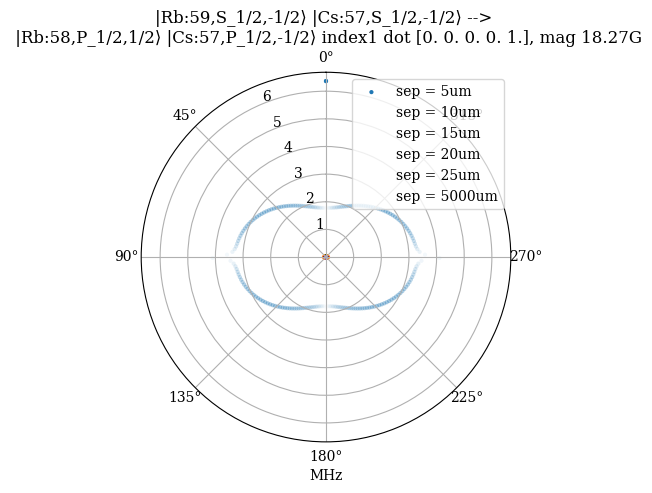

In [69]:
if not os.path.exists(figpath + 'eigenenergies dots\\'):
    os.makedirs(figpath + 'eigenenergies dots\\')
for b in bs:
    for tup in tups:
        for index in range(2):
            fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
            ax.set_theta_zero_location("N")
            for r in rs:


                ax.scatter(np.radians(thetas[f'{r}{b}']),
                        abs(np.array(Ediag[f'{r}{b}'][f'{index}'])),
                        alpha=overlap[f'{r}{b}'][f'{index}{tup}'],
                        marker='.',
                        linewidths=.01,
                        label = fr'sep = {np.round(r,2)}um')
                
            ax.legend()
            ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index} dot {tup}, mag {np.round(b,2)}G')
            ax.set_xlabel('MHz')
            plt.savefig(figpath + f'eigenenergies dots\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), mag {np.round(b,3)}G, e {np.round(e,1)}Vcm evec {index} dot tup.png')

        plt.show()
        plt.close()

In [32]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\2x2 hams avg\\'
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')
if not os.path.exists(figpath + 'energies\\'):
    os.makedirs(figpath + 'energies\\')

Ediags = {f'{mag}' : {
    'state0' : [abs(eval[0]) for eval in eval_list[f'{mag}']],
    'state1' : [abs(eval[1]) for eval in eval_list[f'{mag}']]
} for mag in bs}
print(Ediags)
tup0_overlaps0 = {f'{mag}' : [abs(np.dot([1,0], evec[0])) for evec in evec_list[f'{mag}']] for mag in bs}
tup1_overlaps1 = {f'{mag}' : [abs(np.dot([0,1], evec[1])) for evec in evec_list[f'{mag}']] for mag in bs}
tup0_overlaps1 = {f'{mag}' : [abs(np.dot([1,0], evec[1])) for evec in evec_list[f'{mag}']] for mag in bs}
tup1_overlaps0 = {f'{mag}' : [abs(np.dot([0,1], evec[0])) for evec in evec_list[f'{mag}']] for mag in bs}

print(tup1_overlaps1)

# state0 overlap with tuple 0
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup0_overlaps0[f'{mag}'], label = f'{mag}G') 
ax.set_title('state0 overlap with tuple 0')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlaps\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 0index0.png')
plt.show() 

# state1 overlap with tuple 0
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup0_overlaps1[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state1 overlap with tuple 0')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlaps\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 0index1.png')
plt.show()    

# state0 overlap with tuple 1
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup1_overlaps0[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state0 overlap with tuple 1')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlaps\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 1index0.png')
plt.show()  

# state1 overlap with tuple 1
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup1_overlaps1[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state1 overlap with tuple 1')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlaps\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 1index1.png')
plt.show()



ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(thetaList), np.array(Ediags[f'{mag}']['state0']), "-", label= f'state0 {round(mag, 2)}G')
plt.legend()
ax.set_xlabel(r"$\theta$ (degree)")
ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} ({energy_unit})')
plt.savefig(figpath + f'\\energies\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} index0.png')
plt.show()


ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:   
    ax.plot(np.radians(thetaList), np.array(Ediags[f'{mag}']['state1']), "-", label= f'state1 {round(mag, 2)}G')
    # ax.plot(np.radians(thetaList), J00[f'{mag}'], "-", label = f'off diag {mag}G')
plt.legend()
ax.set_xlabel(r"$\theta$ (degree)")
ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} ({energy_unit})')

plt.savefig(figpath + f'\\energies\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} index1.png')
plt.show()

0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2))
1 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,1/2))


KeyError: '0.0'